# Chaotic Digest Image Encryption
This notebook generates a chaotic sequence using your logistic/digital maps,
compresses the 64‑bit state to an 8‑bit digest, and performs simple XOR
encryption of an image (`5.2.08.tiff`).

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from Graphs import Logistic_map
from Digital_Map import digital_map

In [2]:
def bits64_to_uint8_digest(bits):
    bits = np.asarray(bits)

    if bits.shape[1] != 64:
        raise ValueError('Input must have 64 bits per row')

    B = bits.reshape(-1, 8, 8)
    weights = 2**np.arange(7, -1, -1)

    bytes_ = (B * weights).sum(axis=2).astype(np.uint8)
    digest = np.bitwise_xor.reduce(bytes_, axis=1)

    return digest

In [3]:
img = Image.open('5.2.08.tiff').convert('L')
img_array = np.array(img)

height, width = img_array.shape
n_pixels = height * width

print('Image size:', height, 'x', width)
print('Total pixels:', n_pixels)

Image size: 512 x 512
Total pixels: 262144


In [4]:
N = n_pixels
x0 = 0.123456
k = 64

seq_real = Logistic_map(x0, N-1)
seq_digital, bits = digital_map(x0, N-1, k)

In [5]:
digest = bits64_to_uint8_digest(bits)

print('Digest length:', digest.shape)

Digest length: (262144,)


In [6]:
flat_img = img_array.flatten()

cipher = np.bitwise_xor(flat_img, digest)

encrypted = cipher.reshape(img_array.shape)

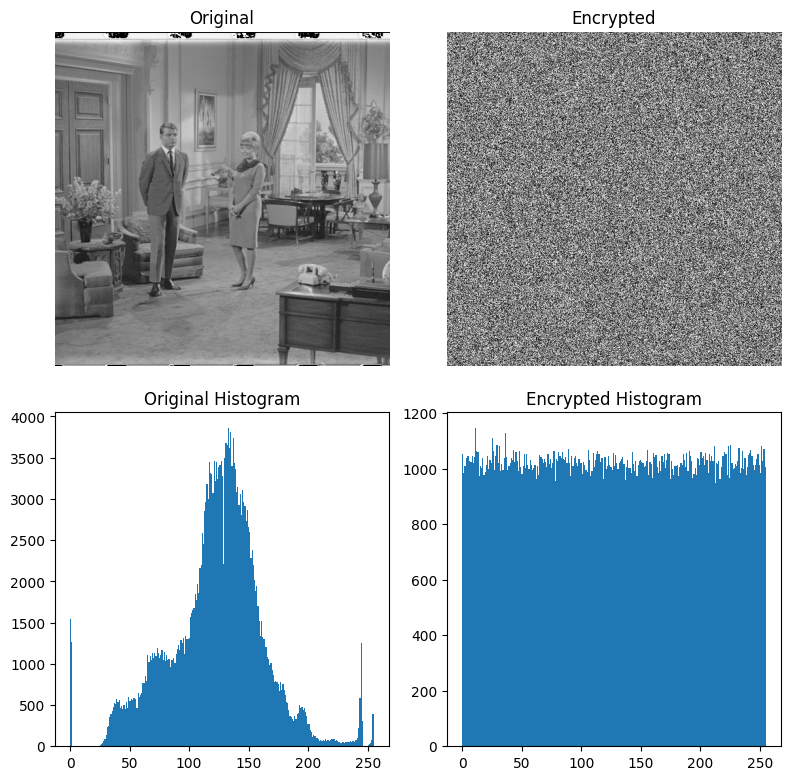

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(8,8))

# -------------------
# Original Image
# -------------------
ax[0,0].imshow(img_array, cmap='gray')
ax[0,0].set_title('Original')
ax[0,0].axis('off')
ax[0,0].set_box_aspect(1)

# -------------------
# Encrypted Image
# -------------------
ax[0,1].imshow(encrypted, cmap='gray')
ax[0,1].set_title('Encrypted')
ax[0,1].axis('off')
ax[0,1].set_box_aspect(1)

# -------------------
# Original Histogram
# -------------------
ax[1,0].hist(img_array.flatten(), bins=256, range=(0,255))
ax[1,0].set_title('Original Histogram')
ax[1,0].set_box_aspect(1)

# -------------------
# Encrypted Histogram
# -------------------
ax[1,1].hist(encrypted.flatten(), bins=256, range=(0,255))
ax[1,1].set_title('Encrypted Histogram')
ax[1,1].set_box_aspect(1)

plt.tight_layout()
# Save figure
plt.savefig("image_encryption_analysis.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:


Image.fromarray(encrypted).save('encrypted_image.png')
print('Encrypted image saved as encrypted_image.png')

Encrypted image saved as encrypted_image.png
